In [16]:
#Lecture 4 — Model Answer
#Scatter & Bubble: Gapminder

import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-nu

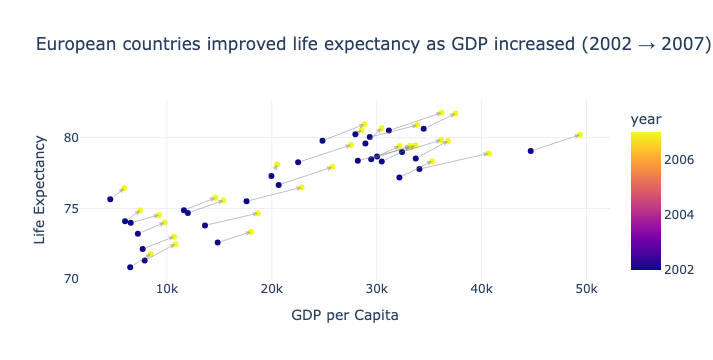

In [5]:

continent_choice = "Europe"
task1_df = df.loc[
    (df["continent"] == continent_choice) &
    (df["year"].isin([2002, 2007]))
]


fig1 = px.scatter(
    task1_df,
    x="gdpPercap",
    y="lifeExp",
    color="year",
    hover_name="country",
    title="European countries improved life expectancy as GDP increased (2002 → 2007)",
    color_discrete_sequence=["#4C78A8", "#F58518"]
)

for country in task1_df["country"].unique():

    country_df = (
        task1_df.loc[task1_df["country"] == country]
        .sort_values("year")
    )

    if len(country_df) == 2:

        fig1.add_annotation(
            x=country_df.iloc[1]["gdpPercap"],
            y=country_df.iloc[1]["lifeExp"],
            ax=country_df.iloc[0]["gdpPercap"],
            ay=country_df.iloc[0]["lifeExp"],
            xref="x",
            yref="y",
            axref="x",
            ayref="y",
            showarrow=True,
            arrowhead=2,
            arrowwidth=1,
            arrowcolor="gray",
            opacity=0.5
        )

fig1.update_layout(
    template="plotly_white",
    xaxis_title="GDP per Capita",
    yaxis_title="Life Expectancy"
)

fig1.show()

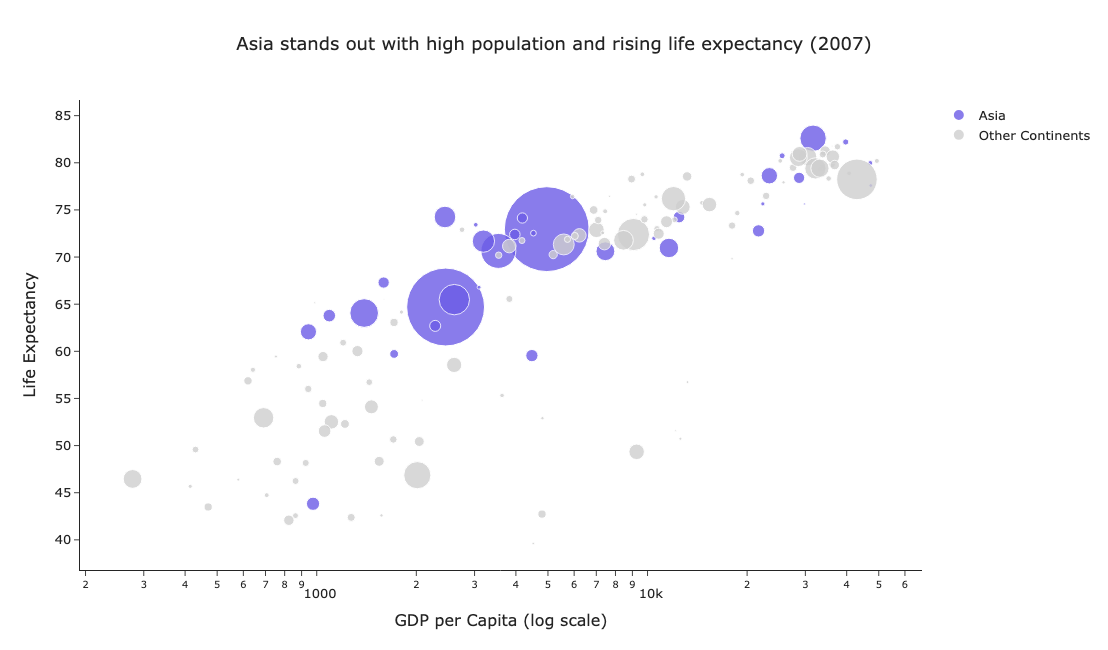

In [11]:

task2_df = df.loc[df["year"] == 2007].copy()


highlight_continent = "Asia"


task2_df["group"] = task2_df["continent"].apply(
    lambda x: highlight_continent if x == highlight_continent else "Other Continents"
)


fig2 = px.scatter(
    task2_df,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="group",
    hover_name="country",
    log_x=True,
    size_max=60,
    title="Asia stands out with high population and rising life expectancy (2007)",
    color_discrete_map={
        highlight_continent: "#6C5CE7",   
        "Other Continents": "#CFCFCF"     
    }
)

# Improve marker appearance
fig2.update_traces(
    marker=dict(
        line=dict(width=1, color="white"),
        opacity=0.8
    )
)

# Add annotation
fig2.add_annotation(
    x=18000,
    y=80,
    text="Asia includes several densely populated<br>countries with improving health outcomes",
    showarrow=True,
    arrowhead=2,
    bordercolor="black",
    borderwidth=1,
    bgcolor="white"
)

fig2.update_layout(
    template="simple_white",
    xaxis_title="GDP per Capita (log scale)",
    yaxis_title="Life Expectancy",
    legend_title="",
    title_x=0.5,
    font=dict(size=13),
    width=1000,
    height=650
)

fig2.show()